# Modelo - DenseNet201

Juan Muelledes Mateos - Trabajo final de Modelado Computacional, Simulacion y Optimización

25-03-2026 Ejecucion del codigo Densenet con Pesos ponderados suavizados, entrenamiento de dos fases, arquitectura original de una capa densa, y uso combinado de Augmentacion offline, focal loss y micup - Precision a superar: 92%, resultado: 91,1%.

30-03-2026 Ejecucion de DenseNet201 incluyendo modulos CBAM (Convolutional Block Attention Module). Precision a superar: 92%.

Mañana: Terminar entrenamiento finetuning y hacer que vaya. Mejorar finetuning y moduilo CBAM.

Mañana Viernes Santo: Hacer entrenamiento con OVersampling. Sino funciona, emplear tambien mejoras de finetuning y CBAM con ACO.

## 1. Importamos las librerias necesarias

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import sklearn
import itertools
from sklearn.metrics import classification_report
from tensorflow.keras.applications import *
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input as base_preprocess
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, RocCurveDisplay, auc
from sklearn.utils.multiclass import unique_labels
from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive
from keras.losses import CategoricalFocalCrossentropy

## 2. Cargamos las imagenes y las etiquetas

In [2]:
drive.mount('/content/drive')

data = np.load('/content/drive/MyDrive/Archivos Modelado/data.npy')
labels = np.load('/content/drive/MyDrive/Archivos Modelado/labels.npy')

Mounted at /content/drive


In [3]:
def random_rotation(img, angle_range=20):
    angle = np.random.uniform(-angle_range, angle_range)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h),
                          borderMode=cv2.BORDER_REFLECT_101)
def random_brightness_contrast(img):
    alpha = np.random.uniform(0.8, 1.2)  # contraste
    beta = np.random.uniform(-25, 25)    # brillo
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

def add_gaussian_noise(img):
    noise = np.random.normal(0, 10, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

def random_zoom(img, zoom_range=(0.9, 1.1)):
    h, w = img.shape[:2]
    scale = np.random.uniform(*zoom_range)

    new_h, new_w = int(h*scale), int(w*scale)
    resized = cv2.resize(img, (new_w, new_h))

    if scale > 1:
        startx = (new_w - w)//2
        starty = (new_h - h)//2
        return resized[starty:starty+h, startx:startx+w]
    else:
        pad_h = (h - new_h)//2
        pad_w = (w - new_w)//2
        return cv2.copyMakeBorder(
            resized,
            pad_h, h-new_h-pad_h,
            pad_w, w-new_w-pad_w,
            cv2.BORDER_REFLECT_101
        )
def random_blur(img):
    k = np.random.choice([3,5])
    return cv2.GaussianBlur(img, (k,k), 0)

In [4]:
def produce_new_img_strong(img):

    augmented = []

    augmented.append(cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE))
    augmented.append(cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE))
    augmented.append(cv2.rotate(img, cv2.ROTATE_180))
    augmented.append(cv2.flip(img, 0))
    augmented.append(cv2.flip(img, 1))
    augmented.append(random_rotation(img))
    augmented.append(random_brightness_contrast(img))
    augmented.append(add_gaussian_noise(img))
    augmented.append(random_zoom(img))
    augmented.append(random_blur(img))

    return augmented

In [5]:
import cv2
from cv2 import imread, resize

def apply_augmentation_to_minority_classes(X_train, y_train_one_hot):

    augmented_images = []
    augmented_labels = []
    y_train_indices = np.argmax(y_train_one_hot, axis=1)
    for img, label_idx in zip(X_train, y_train_indices):
        augmented_images.append(img)
        augmented_labels.append(label_idx)
        if label_idx != 5 and label_idx != 2 and label_idx != 4:  # Después de ordenar, 5 es NV, la clase matyoritaria
            new_imgs = produce_new_img_strong(img)
            for new_img in new_imgs:
                augmented_images.append(new_img)
                augmented_labels.append(label_idx)

    augmented_labels_one_hot = to_categorical(augmented_labels, num_classes=7)
    return np.array(augmented_images), augmented_labels_one_hot

In [6]:
train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.1, stratify=labels, random_state=42
)
train_data, val_data, train_labels, val_labels = train_test_split(
    train_data, train_labels, test_size=0.111, stratify=train_labels, random_state=42
)

In [7]:
train_data, train_labels = apply_augmentation_to_minority_classes(train_data, train_labels)

print("Rango de valores en train_data:", train_data.min(), train_data.max())

train_data = (train_data / 127.5) - 1.0
val_data = (val_data / 127.5) - 1.0
test_data = (test_data / 127.5) - 1.0

print("Rango de valores en train_data:", train_data.min(), train_data.max())

Rango de valores en train_data: 0 255
Rango de valores en train_data: -1.0 1.0


## 3. Dividimos los datos a conjuntos de entrenamiento, validación y test

In [8]:
print("train_data shape:", train_data.shape)
print("train_labels shape:", train_labels.shape)
print("val_data shape:", val_data.shape)
print("val_labels shape:", val_labels.shape)
print("test_data shape:", test_data.shape)
print("test_labels shape:", test_labels.shape)

train_data shape: (16792, 224, 224, 3)
train_labels shape: (16792, 7)
val_data shape: (1001, 224, 224, 3)
val_labels shape: (1001, 7)
test_data shape: (1002, 224, 224, 3)
test_labels shape: (1002, 7)


In [9]:
class_names_mapping = {
    0: "AKIEC",
    1: "BCC",
    2: "BKL",
    3: "DF",
    4: "MEL",
    5: "NV",
    6: "VASC"
}

num_classes = train_labels.shape[1]
class_counts_train = np.sum(train_labels, axis=0)
class_counts_val = np.sum(val_labels, axis=0)
class_counts_test = np.sum(test_labels, axis=0)

class_counts_mapping = {}
for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name] = {'Train': class_counts_train[index]}

for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name]['Validation'] = class_counts_val[index]

for index, class_name in class_names_mapping.items():
    class_counts_mapping[class_name]['Test'] = class_counts_test[index]

for class_name, counts in class_counts_mapping.items():
    print(class_name)
    for set_name, count in counts.items():
        print(f" - {set_name}: {count}")

y_train_integers = np.argmax(train_labels, axis=1)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_integers),
    y=y_train_integers
)

class_weight_dict = dict(enumerate(class_weights))

class_weight_dict = {i: np.sqrt(w) for i, w in class_weight_dict.items()}

print("\n Pesos para cada clase para paliar desbalance:")
for cls, weight in class_weight_dict.items():
    print(f"Class {class_names_mapping[cls]}: {weight:.4f}")

AKIEC
 - Train: 2871.0
 - Validation: 33.0
 - Test: 33.0
BCC
 - Train: 4532.0
 - Validation: 51.0
 - Test: 51.0
BKL
 - Train: 879.0
 - Validation: 110.0
 - Test: 110.0
DF
 - Train: 1001.0
 - Validation: 12.0
 - Test: 12.0
MEL
 - Train: 891.0
 - Validation: 111.0
 - Test: 111.0
NV
 - Train: 5364.0
 - Validation: 670.0
 - Test: 671.0
VASC
 - Train: 1254.0
 - Validation: 14.0
 - Test: 14.0

 Pesos para cada clase para paliar desbalance:
Class AKIEC: 0.9141
Class BCC: 0.7275
Class BKL: 1.6520
Class DF: 1.5481
Class MEL: 1.6408
Class NV: 0.6687
Class VASC: 1.3831


## 4. Definimos los elementos necesarios para el entrenamiento

### 4.0 ACO

In [ ]:
"""param_grid = {
    'learning_rate': [1e-3, 5e-4, 1e-4, 5e-5],
    'batch_size': [8, 16, 24, 32],
    'dropout_rate': [0.3, 0.5, 0.7],
    'focal_gamma': [1.0, 2.0, 2.5, 3.0],
    'label_smoothing': [0.0, 0.05, 0.1],
}

In [ ]:
""""import numpy as np
from copy import deepcopy

class AntColonyOptimizer:
    def __init__(self, param_grid, n_ants=10, n_iterations=20,
                 evaporation_rate=0.5, pheromone_deposit_weight=1.0):
        self.param_grid = param_grid
        self.n_ants = n_ants
        self.n_iterations = n_iterations
        self.evaporation_rate = evaporation_rate
        self.pheromone_deposit_weight = pheromone_deposit_weight

        # Inicializar feromonas y mejor solución conocida
        self.pheromone_trails = {}
        self.best_solution = None
        self.best_score = -np.inf
        self._initialize_pheromones()

    def _initialize_pheromones(self):
        """Inicializa los niveles de feromona para cada hiperparámetro."""
        for param, values in self.param_grid.items():
            self.pheromone_trails[param] = {val: 1.0 for val in values}

    def _choose_value(self, param, pheromones):
        """Selecciona un valor para un hiperparámetro basado en las feromonas."""
        values = self.param_grid[param]
        probs = []
        for val in values:
            prob = pheromones[val] ** self.pheromone_deposit_weight
            probs.append(prob)
        probs = np.array(probs) / np.sum(probs)
        return np.random.choice(values, p=probs)

    def _construct_ant_solution(self):
        """Una hormiga 'construye' una solución eligiendo valores para cada parámetro."""
        solution = {}
        for param, pheromones in self.pheromone_trails.items():
            solution[param] = self._choose_value(param, pheromones)
        return solution

    def optimize(self, evaluate_func):
        """Bucle principal de optimización ACO."""
        for iteration in range(self.n_iterations):
            # Cada hormiga construye una solución y la evalúa
            solutions = []
            scores = []

            for ant in range(self.n_ants):
                solution = self._construct_ant_solution()
                score = evaluate_func(solution)

                solutions.append(solution)
                scores.append(score)

                # Actualizar la mejor solución global
                if score > self.best_score:
                    self.best_score = score
                    self.best_solution = deepcopy(solution)
                    print(f"Nueva mejor solución encontrada: {solution} -> {score:.4f}")

            # Actualizar niveles de feromona (evaporación + depósito)
            for param, values in self.param_grid.items():
                for val in values:
                    # Evaporación
                    self.pheromone_trails[param][val] *= (1 - self.evaporation_rate)

            # Depósito de feromona (basado en el rendimiento)
            for solution, score in zip(solutions, scores):
                for param, val in solution.items():
                    # Normalizar el score para evitar sesgos
                    normalized_score = max(0.0, (score + 1) / 2)
                    self.pheromone_trails[param][val] += normalized_score

        return self.best_solution, self.best_score

In [ ]:
"""def evaluate_hyperparams(params):

    base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224,224,3))
    x = base_model.output
    x = CBAM(reduction=16)(x)   # Asegúrate de que CBAM está definida
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(params['dropout_rate'])(x)
    predictions = Dense(7, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)

    if params['label_smoothing'] > 0:
        loss_fn = CategoricalFocalCrossentropy(
            alpha=alpha_list,
            gamma=params['focal_gamma'],
            label_smoothing=params['label_smoothing']
        )
    else:
        loss_fn = CategoricalFocalCrossentropy(
            alpha=alpha_list,
            gamma=params['focal_gamma']
        )

    model.compile(optimizer=Adam(learning_rate=params['learning_rate']),
                  loss=loss_fn,
                  metrics=['accuracy'])

    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )

    history = model.fit(
        datagen.flow(train_data, train_labels, batch_size=params['batch_size']),
        validation_data=(val_data, val_labels),
        epochs=5,
        verbose=0
    )

    best_val_acc = max(history.history['val_accuracy'])
    return best_val_acc

In [ ]:
""""aco = AntColonyOptimizer(param_grid, n_ants=5, n_iterations=10)
best_params, best_score = aco.optimize(evaluate_hyperparams)
print("Mejores parámetros encontrados:", best_params)
print("Mejor precisión de validación (rápida):", best_score)

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


### 4.1 Generador de datos aumentados

In [10]:
batch_size = 16

alpha_list = [class_weight_dict[i] for i in range(num_classes)]  # ya es lista de floats

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [11]:
class MixupSequence(tf.keras.utils.Sequence):
    def __init__(self, x, y, batch_size, datagen, alpha=0.2, shuffle=True):
        self.x = x
        self.y = y
        self.batch_size = batch_size
        self.datagen = datagen
        self.alpha = alpha
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.x) / self.batch_size))

    def on_epoch_end(self):
        self.indices = np.arange(len(self.x))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_x = self.x[batch_indices].copy()
        batch_y = self.y[batch_indices].copy()

        # Aplicar transformaciones aleatorias a cada imagen
        for i in range(len(batch_x)):
            batch_x[i] = self.datagen.random_transform(batch_x[i])

        # Mezclar con MixUp
        lam = np.random.beta(self.alpha, self.alpha)
        idx_perm = np.random.permutation(len(batch_x))
        mixed_x = lam * batch_x + (1 - lam) * batch_x[idx_perm]
        mixed_y = lam * batch_y + (1 - lam) * batch_y[idx_perm]
        return mixed_x, mixed_y

train_gen = MixupSequence(train_data, train_labels,
                          batch_size=batch_size,
                          datagen=datagen,
                          alpha=0.2)

### 4.2 Funciones de Callback

In [12]:
lr_reduce = ReduceLROnPlateau(monitor = 'val_accuracy', factor = 0.5, patience = 5,mode='max', min_lr = 1e-5,verbose = 1)
early_stop = EarlyStopping(monitor = 'val_accuracy', patience = 10, mode='max', verbose = 1)
saved_model = '/content/drive/MyDrive/SC Lab/Saved Model/Final Training/DenseNet201.keras'
model_chkpt = ModelCheckpoint(saved_model ,save_best_only = True, monitor = 'val_accuracy',verbose = 1)

callback_list = [early_stop, model_chkpt, lr_reduce]

### 4.3 Modelo DenseNet201

In [13]:
base_model = DenseNet201(weights='imagenet',
                      include_top=False,
                      input_shape=(224, 224, 3))

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [14]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Multiply, Add, Reshape, Conv2D

class CBAM(Layer):
    def __init__(self, reduction=16, **kwargs):
        super(CBAM, self).__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        channels = input_shape[-1]
        self.dense1 = Dense(channels // self.reduction, activation='relu', use_bias=False)
        self.dense2 = Dense(channels, activation='sigmoid', use_bias=False)
        self.spatial_conv = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')
        super(CBAM, self).build(input_shape)

    def call(self, inputs):

        avg_pool = GlobalAveragePooling2D()(inputs)
        max_pool = GlobalMaxPooling2D()(inputs)
        avg_out = self.dense2(self.dense1(avg_pool))
        max_out = self.dense2(self.dense1(max_pool))
        channel_attention = Add()([avg_out, max_out])
        channel_attention = Reshape((1, 1, inputs.shape[-1]))(channel_attention)
        channel_refined = Multiply()([inputs, channel_attention])

        avg_pool_s = tf.reduce_mean(channel_refined, axis=-1, keepdims=True)
        max_pool_s = tf.reduce_max(channel_refined, axis=-1, keepdims=True)
        spatial_concat = tf.concat([avg_pool_s, max_pool_s], axis=-1)
        spatial_attention = self.spatial_conv(spatial_concat)
        spatial_refined = Multiply()([channel_refined, spatial_attention])
        return spatial_refined

    def compute_output_shape(self, input_shape):
        return input_shape

In [15]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Multiply, Add, Reshape, Conv2D, AveragePooling2D
from tensorflow.keras import backend as K

class CBAMImproved(Layer):
    def __init__(self, reduction=16, **kwargs):
        super(CBAMImproved, self).__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        channels = input_shape[-1]

        self.dense1 = Dense(channels // self.reduction, activation='relu', use_bias=False)
        self.dense2 = Dense(channels, activation='sigmoid', use_bias=False)

        # --- Capas de Atención Espacial Mejorada ---
        # Convolución para combinar los mapas de atención espacial
        self.spatial_conv = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')
        # Capa de pooling para la rama multi-escala
        self.multi_scale_pool = AveragePooling2D(pool_size=2, strides=2)

        super(CBAMImproved, self).build(input_shape)

    def call(self, inputs):
        # --- 1. Atención de Canal ---
        avg_pool = GlobalAveragePooling2D()(inputs)
        max_pool = GlobalMaxPooling2D()(inputs)

        avg_out = self.dense2(self.dense1(avg_pool))
        max_out = self.dense2(self.dense1(max_pool))
        channel_attention = Add()([avg_out, max_out])
        channel_attention = Reshape((1, 1, inputs.shape[-1]))(channel_attention)
        channel_refined = Multiply()([inputs, channel_attention])

        # --- 2. Atención Espacial Mejorada ---
        # Rama de promedio y máximo (para detalles finos)
        avg_pool_s = tf.reduce_mean(channel_refined, axis=-1, keepdims=True)
        max_pool_s = tf.reduce_max(channel_refined, axis=-1, keepdims=True)

        # Nueva rama multi-escala (para patrones globales)
        pool_ms = self.multi_scale_pool(channel_refined)
        pool_ms = tf.reduce_mean(pool_ms, axis=-1, keepdims=True)
        pool_ms_resized = tf.image.resize(pool_ms, tf.shape(channel_refined)[1:3])

        # Concatenar los 3 mapas de atención espacial
        spatial_concat = tf.concat([avg_pool_s, max_pool_s, pool_ms_resized], axis=-1)
        spatial_attention = self.spatial_conv(spatial_concat)

        # Refinar la salida final
        refined_output = Multiply()([channel_refined, spatial_attention])
        return refined_output

    def get_config(self):
        config = super().get_config()
        config.update({"reduction": self.reduction})
        return config

In [16]:
x = base_model.output
x = CBAMImproved(reduction=16)(x)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(7, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

loss_fn = CategoricalFocalCrossentropy(alpha=alpha_list, gamma=2.0)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=loss_fn,
              metrics=['accuracy'])

In [ ]:
# 1. Base del modelo DenseNet201
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output

x = CBAM(reduction=16)(x)

x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

loss_fn = CategoricalFocalCrossentropy(alpha=alpha_list, gamma=2.0)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss=loss_fn,
              metrics=['accuracy'])

### 4.4 Entrenamiento Fase 1

In [17]:
history = model.fit(datagen.flow(train_data, train_labels, batch_size=16),
                    validation_data=(val_data, val_labels),
                    epochs=50,
                    callbacks=callback_list)

Epoch 1/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.6361 - loss: 0.6337
Epoch 1: val_accuracy improved from None to 0.81219, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/DenseNet201.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/DenseNet201.keras
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 1174s 690ms/step - accuracy: 0.7283 - loss: 0.4454 - val_accuracy: 0.8122 - val_loss: 0.3852 - learning_rate: 1.0000e-04
Epoch 2/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8259 - loss: 0.2556
Epoch 2: val_accuracy did not improve from 0.81219
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 172s 164ms/step - accuracy: 0.8287 - loss: 0.2480 - val_accuracy: 0.7383 - val_loss: 0.3771 - learning_rate: 1.0000e-04
Epoch 3/50
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.8462 - loss: 0.2021
Epoch 3: val_accuracy did not improve from 0.81219
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 171s 163ms/step - accuracy: 0.8564 - los

### 4.5 Entrenamiento Fase 2

In [18]:
model.load_weights(saved_model)
base_model.trainable = True

for layer in base_model.layers[:-100]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-6),
              loss="categorical_crossentropy",
              metrics=['accuracy'])

fine_lr_reduce = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, mode='max', min_lr=1e-8, verbose=1)
fine_early_stop = EarlyStopping(monitor='val_accuracy', min_delta=0.001, patience=8, verbose=1)
fine_checkpoint = ModelCheckpoint(saved_model.replace('.h5', '_finetuned.h5'), save_best_only=True, monitor='val_accuracy', verbose=1)

fine_callbacks = [fine_checkpoint, fine_lr_reduce, fine_early_stop]

fine_tune_epochs = 15
history_fine = model.fit(datagen.flow(train_data, train_labels, batch_size=batch_size),
                         validation_data=(val_data, val_labels),
                         epochs=fine_tune_epochs,
                         callbacks=fine_callbacks)

Epoch 1/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9988 - loss: 0.0141
Epoch 1: val_accuracy improved from None to 0.90010, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/DenseNet201.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/DenseNet201.keras
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 349s 260ms/step - accuracy: 0.9987 - loss: 0.0135 - val_accuracy: 0.9001 - val_loss: 0.3854 - learning_rate: 1.0000e-06
Epoch 2/15
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9974 - loss: 0.0124
Epoch 2: val_accuracy improved from 0.90010 to 0.90110, saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/DenseNet201.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SC Lab/Saved Model/Final Training/DenseNet201.keras
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 172s 163ms/step - accuracy: 0.9983 - loss: 0.0108 - val_accuracy: 0.9011 - val_loss: 0.4017 - learning_rate: 1.0000e-06
Epoch 3

## 6. Evaluamos el modelo

In [19]:
test_loss, test_accuracy = model.evaluate(test_data, test_labels)
print("Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 942ms/step - accuracy: 0.9062 - loss: 0.3780
Test Accuracy: 0.9061876535415649


### 6.2 Informe de clasificación del modelo

In [ ]:
predictions = model.predict(test_data)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels, axis=1)
report = classification_report(true_labels, predicted_labels)

print("Classification Report:")
print(report)

84/84 ━━━━━━━━━━━━━━━━━━━━ 48s 301ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       196
           1       1.00      0.98      0.99       308
           2       0.96      1.00      0.98       660
           3       1.00      1.00      1.00        69
           4       0.96      1.00      0.98       668
           5       1.00      0.94      0.97       671
           6       1.00      1.00      1.00        85

    accuracy                           0.98      2657
   macro avg       0.99      0.99      0.99      2657
weighted avg       0.98      0.98      0.98      2657



### 6.3 Matriz de confusion

In [ ]:
cm = confusion_matrix(true_labels, np.round(predicted_labels))
cm

array([[193,   0,   3,   0,   0,   0,   0],
       [  0, 302,   5,   0,   1,   0,   0],
       [  0,   0, 660,   0,   0,   0,   0],
       [  0,   0,   0,  69,   0,   0,   0],
       [  0,   0,   1,   0, 667,   0,   0],
       [  0,   0,  15,   0,  26, 630,   0],
       [  0,   0,   0,   0,   0,   0,  85]])

Normalized confusion matrix


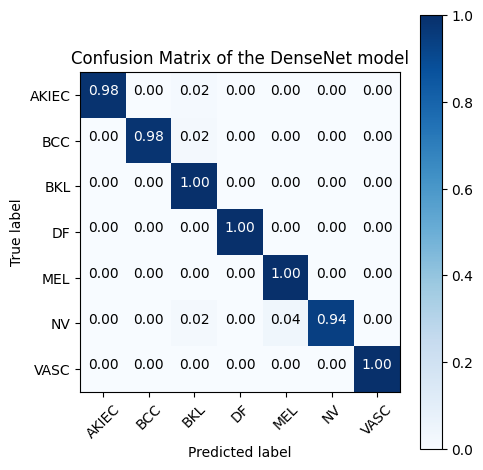

In [ ]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

cm_plot_labels = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']

plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix of the DenseNet model', normalize=True)

Text(0.5, 1.0, 'Accuracy Curves')

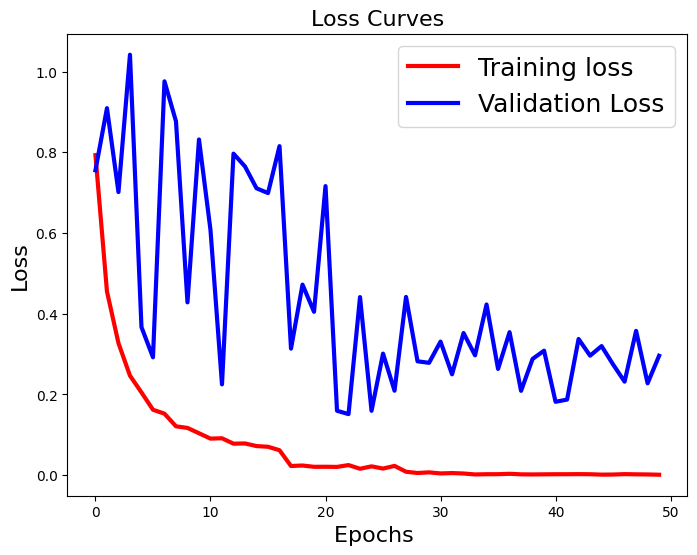

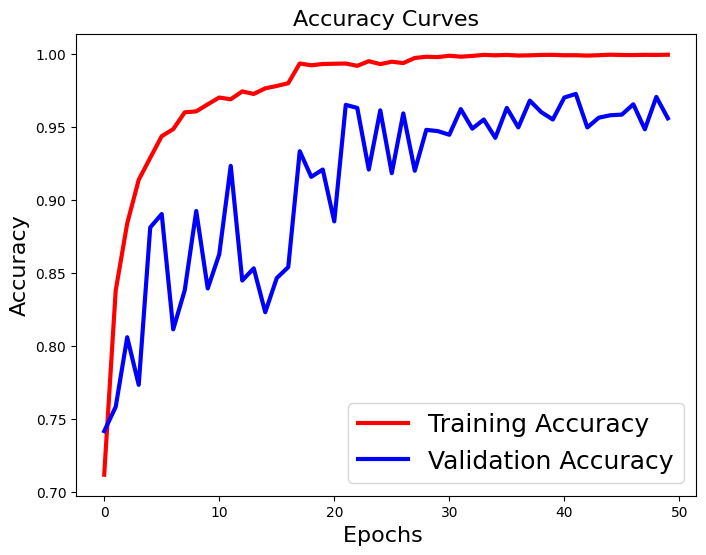

In [ ]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

# Accuracy Curves
plt.figure(figsize=[8,6])
plt.plot(history.history['accuracy'],'r',linewidth=3.0)
plt.plot(history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)